In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Unzip dataset
!unzip /content/drive/MyDrive/SkinCancer_Project.zip -d /content/

import os
import matplotlib.pyplot as plt

# Define dataset paths
dataset_dirs = {
    "Train": "/content/SkinCancer_Project/train",
    "Validation": "/content/SkinCancer_Project/validation",
    "Test": "/content/SkinCancer_Project/test"
}

Mounted at /content/drive
Archive:  /content/drive/MyDrive/SkinCancer_Project.zip
   creating: /content/SkinCancer_Project/
   creating: /content/SkinCancer_Project/test/
   creating: /content/SkinCancer_Project/test/benign/
  inflating: /content/SkinCancer_Project/test/benign/1.jpg  
  inflating: /content/SkinCancer_Project/test/benign/10.jpg  
  inflating: /content/SkinCancer_Project/test/benign/11.jpg  
  inflating: /content/SkinCancer_Project/test/benign/15.jpg  
  inflating: /content/SkinCancer_Project/test/benign/16.jpg  
  inflating: /content/SkinCancer_Project/test/benign/18.jpg  
  inflating: /content/SkinCancer_Project/test/benign/2.jpg  
  inflating: /content/SkinCancer_Project/test/benign/31.jpg  
  inflating: /content/SkinCancer_Project/test/benign/37.jpg  
  inflating: /content/SkinCancer_Project/test/benign/44.jpg  
  inflating: /content/SkinCancer_Project/test/benign/45.jpg  
  inflating: /content/SkinCancer_Project/test/benign/5.jpg  
  inflating: /content/SkinCancer_P

📌 Dataset Summary:
Train Set: 2110 images (Benign: 1152, Malignant: 958)
Validation Set: 527 images (Benign: 288, Malignant: 239)
Test Set: 50 images (Benign: 25, Malignant: 25)


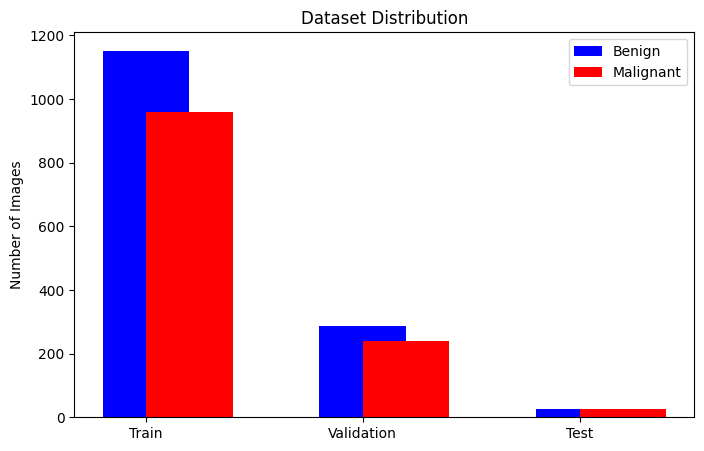

In [2]:
# 1. Dataset Summary information, Visualization
# Count images in each category
dataset_summary = {}
for dataset, path in dataset_dirs.items():
    benign_count = len(os.listdir(os.path.join(path, "benign")))
    malignant_count = len(os.listdir(os.path.join(path, "malignant")))
    dataset_summary[dataset] = (benign_count, malignant_count)

# Print dataset summary
print("📌 Dataset Summary:")
for dataset, (benign, malignant) in dataset_summary.items():
    print(f"{dataset} Set: {benign + malignant} images (Benign: {benign}, Malignant: {malignant})")

# Plot dataset distribution
labels = list(dataset_summary.keys())
benign_counts = [dataset_summary[key][0] for key in labels]
malignant_counts = [dataset_summary[key][1] for key in labels]

plt.figure(figsize=(8, 5))
plt.bar(labels, benign_counts, width=0.4, label="Benign", color='blue', align='center')
plt.bar(labels, malignant_counts, width=0.4, label="Malignant", color='red', align='edge')
plt.ylabel("Number of Images")
plt.title("Dataset Distribution")
plt.legend()
plt.show()

In [3]:
# 2. Model Summary
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.applications import VGG16

# Load VGG16
base_model = VGG16(weights="imagenet", include_top=False, input_shape=(224, 224, 3))

# Freeze base model layers
for layer in base_model.layers:
    layer.trainable = False

# Build model
model = Sequential([
    base_model,
    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')  # Binary classification
])

# Print Model Summary
model.summary()


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)                   │ (None, 7, 7, 512)           │      14,714,688 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │      12,845,568 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             513 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 27,560,769 (105.14 MB)

 Trainable params: 12,846,081 (49.00 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

Found 2110 images belonging to 2 classes.
Found 527 images belonging to 2 classes.
Epoch 1/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 20s 262ms/step - accuracy: 0.8729 - loss: 0.2758 - val_accuracy: 0.8596 - val_loss: 0.3327
Epoch 2/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 15s 226ms/step - accuracy: 0.8911 - loss: 0.2455 - val_accuracy: 0.8311 - val_loss: 0.3733
Epoch 3/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 15s 221ms/step - accuracy: 0.8941 - loss: 0.2555 - val_accuracy: 0.8482 - val_loss: 0.3324
Epoch 4/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 14s 216ms/step - accuracy: 0.9070 - loss: 0.2276 - val_accuracy: 0.8501 - val_loss: 0.3462
Epoch 5/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 14s 215ms/step - accuracy: 0.8938 - loss: 0.2359 - val_accuracy: 0.8672 - val_loss: 0.3233
Epoch 6/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 14s 216ms/step - accuracy: 0.8775 - loss: 0.2547 - val_accuracy: 0.8577 - val_loss: 0.3307
Epoch 7/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 14s 218ms/step - accuracy: 0.8895 - loss: 0.2404 - val_accuracy: 0.8463 - val_loss: 0.3515
Epoch 8/10
66/

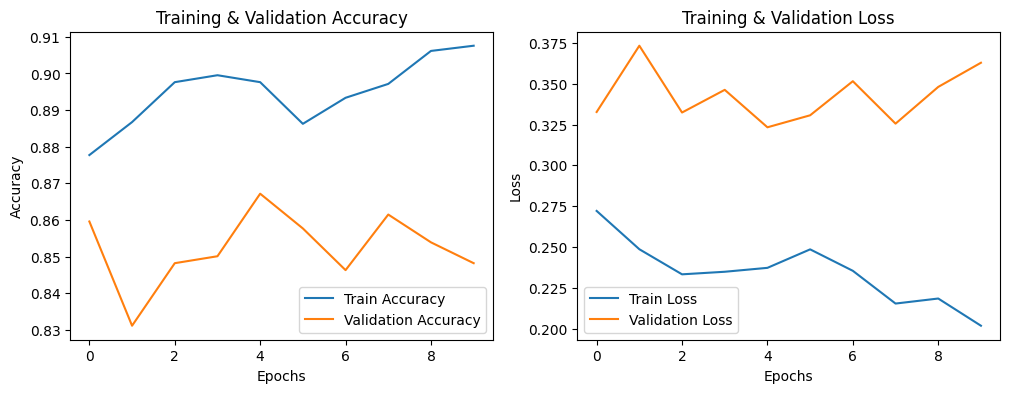

In [6]:
# 3. Epoch status with accuracy
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Data preprocessing
train_dir = "/content/SkinCancer_Project/train"
val_dir = "/content/SkinCancer_Project/validation"

train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(train_dir, target_size=(224, 224), batch_size=32, class_mode='binary')
val_data = val_datagen.flow_from_directory(val_dir, target_size=(224, 224), batch_size=32, class_mode='binary')

# Compile model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train model
history = model.fit(train_data, validation_data=val_data, epochs=10)


model.save('/content/drive/MyDrive/vgg16_skin_cancer_model.keras')

# Plot Accuracy & Loss
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training & Validation Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training & Validation Loss')
plt.legend()

plt.show()


In [7]:
# 4. Evaluate the Model Performance
model = tf.keras.models.load_model('/content/drive/MyDrive/vgg16_skin_cancer_model.keras')
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Evaluate model
val_loss, val_acc = model.evaluate(val_data)
print(f"✅ Final Model Accuracy: {val_acc * 100:.2f}%")



17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 184ms/step - accuracy: 0.8368 - loss: 0.3677
✅ Final Model Accuracy: 84.82%


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━

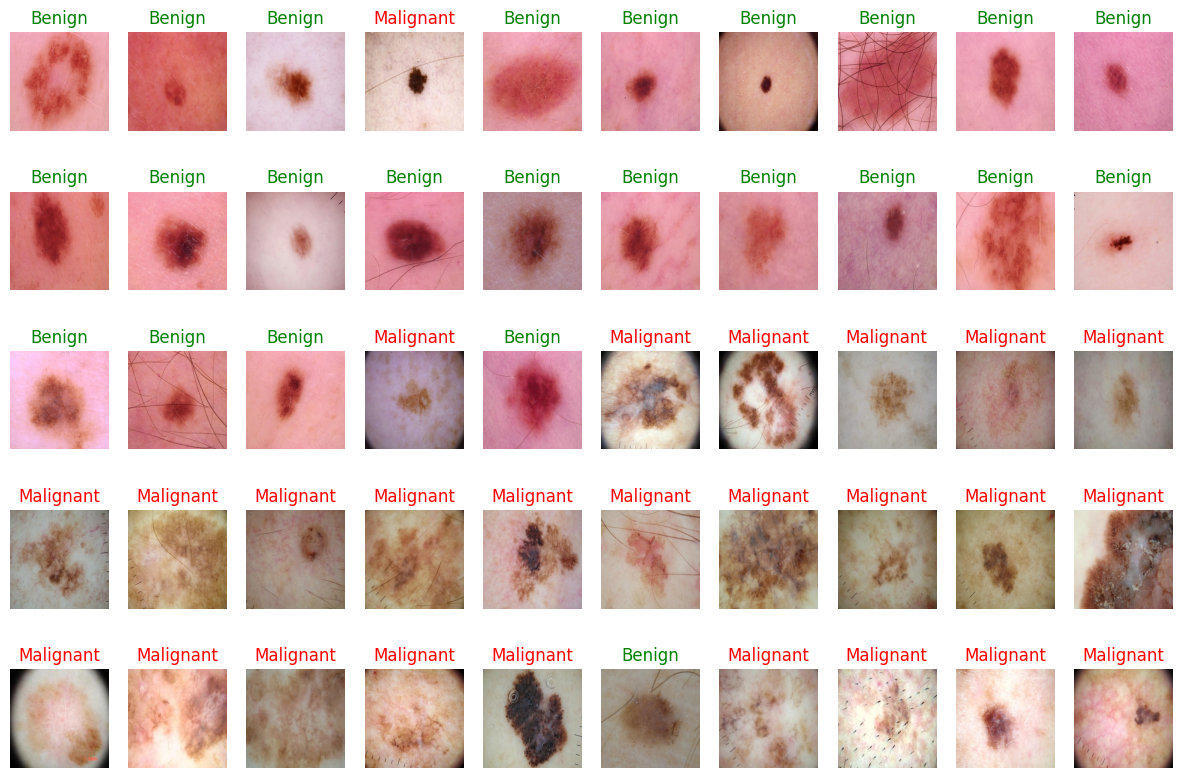

In [10]:
# Test Each test data and display the classification result
from sklearn.metrics import classification_report
import numpy as np
import os
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img, img_to_array

# Define test dataset path
test_dir = "/content/SkinCancer_Project/test"

# Prepare test images & labels
y_true = []
y_pred = []
class_map = {"benign": 0, "malignant": 1}

for category in ["benign", "malignant"]:
    category_path = os.path.join(test_dir, category)
    images = os.listdir(category_path)[:25]  # Limit to 25 images per class

    for img_name in images:
        img_path = os.path.join(category_path, img_name)
        img = load_img(img_path, target_size=(224, 224))
        img_array = img_to_array(img) / 255.0
        img_array = np.expand_dims(img_array, axis=0)

        # Make prediction
        prediction = model.predict(img_array)[0][0]
        y_pred.append(int(prediction > 0.5))
        y_true.append(class_map[category])

# Generate classification report
class_names = ["Benign", "Malignant"]
report = classification_report(y_true, y_pred, target_names=class_names)
print("📌 Classification Report:\n", report)

# ✅ Fix: Define image_paths before using it
image_paths = []
for category in ["benign", "malignant"]:
    category_path = os.path.join(test_dir, category)
    images = os.listdir(category_path)[:25]  # Select first 25 images per class
    image_paths.extend([os.path.join(category_path, img) for img in images])

# Display predictions for all test images
plt.figure(figsize=(15, 10))
for i, img_path in enumerate(image_paths):
    img = load_img(img_path, target_size=(224, 224))
    img_array = img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array)[0][0]
    class_name = "Malignant" if prediction > 0.5 else "Benign"

    ax = plt.subplot(5, 10, i+1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(class_name, color="red" if class_name == "Malignant" else "green")

plt.show()

